In [26]:
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt
from collections import Counter

## 1. Выполните сохранение монохромного изображения в виде текстового или бинарного файла.

In [27]:
image = cv.imread('sar_1_gray.jpg')
image_gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
_, mono_image = cv.threshold(image_gray, 128, 255, cv.THRESH_BINARY)

### Сохраняем изображение в mono_image.txt

In [28]:
np.savetxt('mono_image.txt', mono_image, fmt="%d")

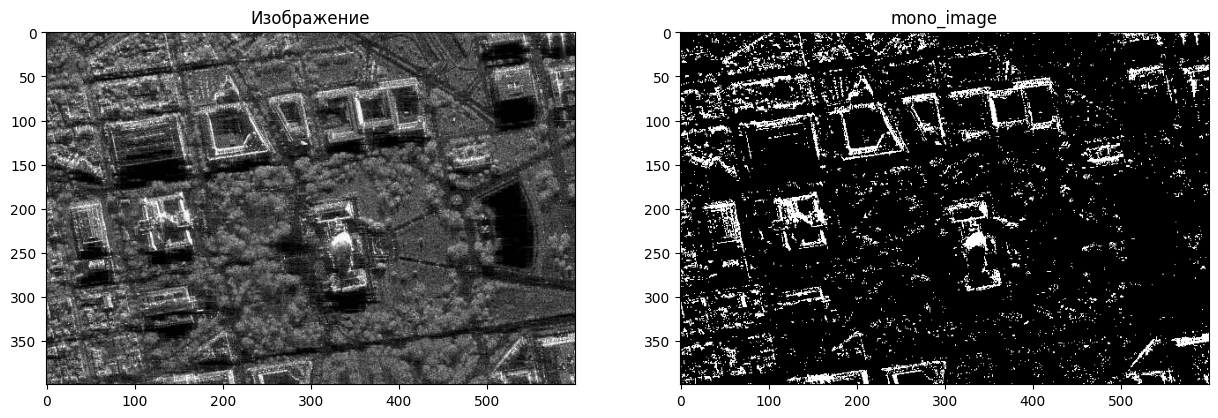

In [29]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Изображение')

plt.subplot(1, 2, 2)
plt.imshow(mono_image, cmap='gray')
plt.title('mono_image')

plt.show()

## 2. Реализуйте алгоритм вейвлет-преобразования Хаара для изображения.

In [30]:
def haar_transform(image):
    image = image.astype(np.float32)
    h, w = image.shape
    temp = np.zeros_like(image)
    for i in range(h):
        for j in range(0, w, 2):
            if j + 1 < w:
                temp[i, j // 2] = (image[i, j] + image[i, j + 1]) / 2
                temp[i, j // 2 + w // 2] = (image[i, j] - image[i, j + 1]) / 2
            else:
                temp[i, j // 2] = image[i, j]
    result = np.zeros_like(temp)
    
    for j in range(w):
        for i in range(0, h, 2):
            if i + 1 < h:
                result[i // 2, j] = (temp[i, j] + temp[i + 1, j]) / 2
                result[i // 2 + h // 2, j] = (temp[i, j] - temp[i + 1, j]) / 2
            else:
                result[i // 2, j] = temp[i, j]
    
    ll = result[:h // 2, :w // 2]
    lh = result[:h // 2, w // 2:]
    hl = result[h // 2:, :w // 2]
    hh = result[h // 2:, w // 2:]

    return ll, lh, hl, hh, result

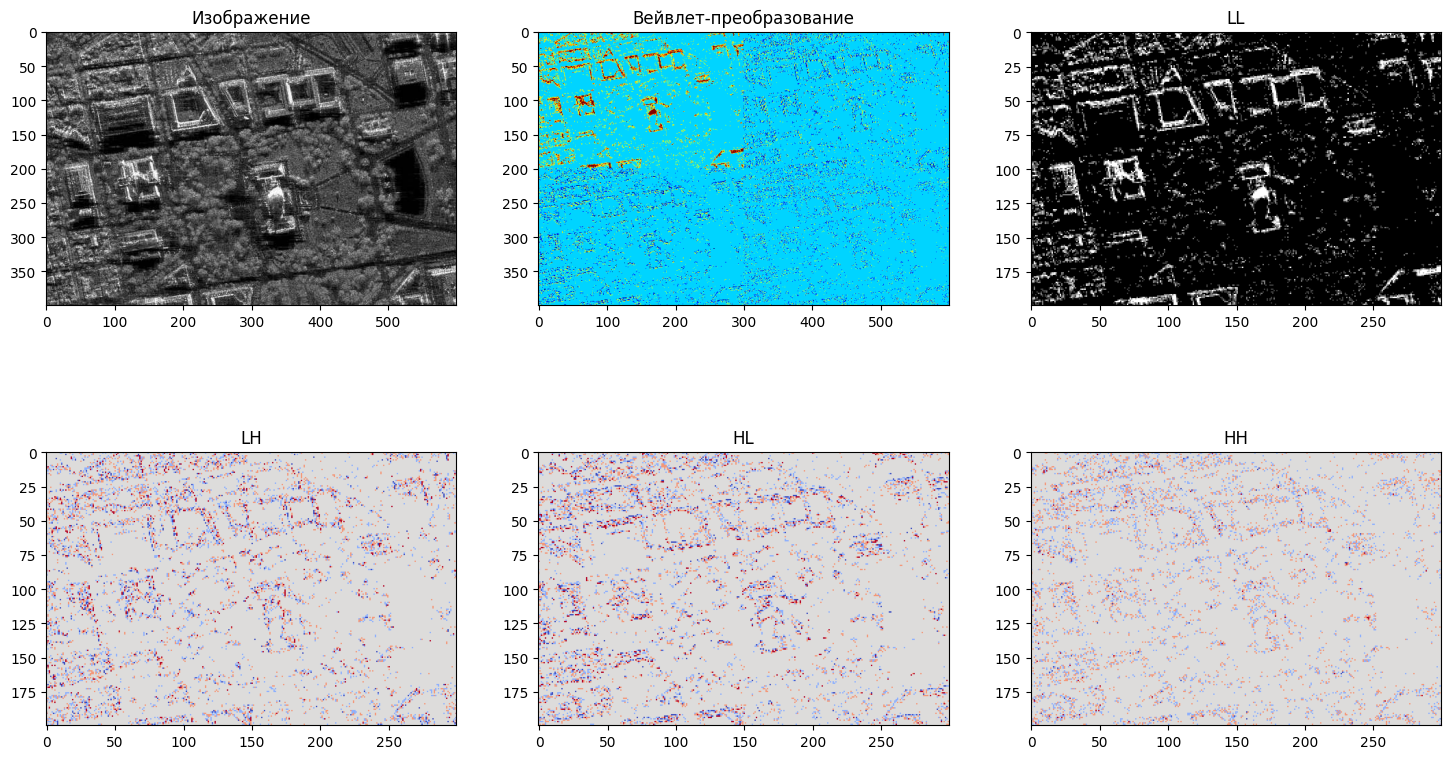

In [31]:
ll, lh, hl, hh, haar_result = haar_transform(mono_image)
plt.figure(figsize=(18, 10))
plt.subplot(2, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('Изображение')

plt.subplot(2, 3, 2)
plt.imshow(haar_result, cmap='jet')
plt.title('Вейвлет-преобразование')

plt.subplot(2, 3, 3)
plt.imshow(ll, cmap='gray')
plt.title('LL')

plt.subplot(2, 3, 4)
plt.imshow(lh, cmap='coolwarm')
plt.title('LH')

plt.subplot(2, 3, 5)
plt.imshow(hl, cmap='coolwarm')
plt.title('HL')

plt.subplot(2, 3, 6)
plt.imshow(hh, cmap='coolwarm')
plt.title('HH')

plt.show()

## 3. Выполните квантование высокочастотных компонент (прим., количество квантов = 4).

In [32]:
def quantize(k, n):
    min_val = np.min(k)
    max_val = np.max(k)
    step = (max_val - min_val) / n
    quantized = np.round((k - min_val) / step).astype(int)
    return quantized

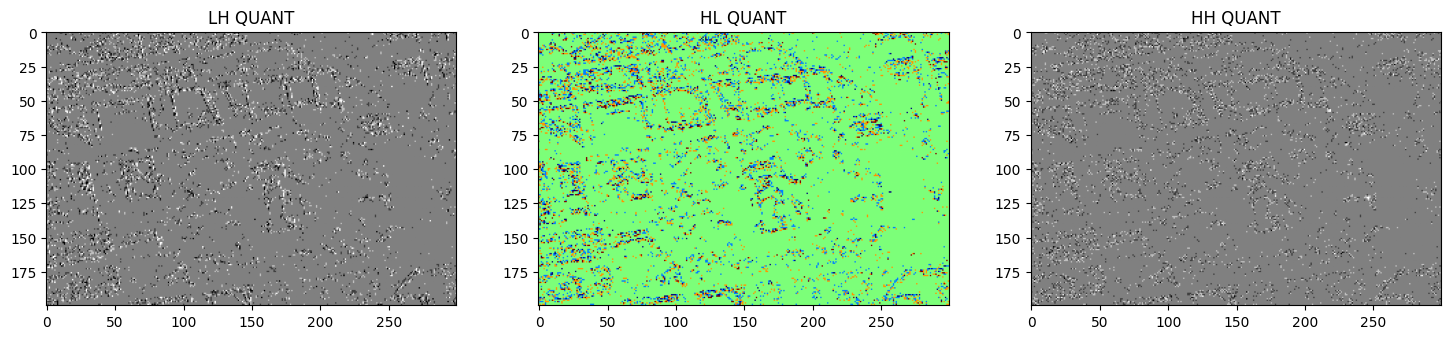

In [33]:
lh_q = quantize(lh, 4)
hl_q = quantize(hl, 4)
hh_q = quantize(hh, 4)

plt.figure(figsize=(18, 10))
plt.subplot(1, 3, 1)
plt.imshow(lh_q, cmap='gray')
plt.title('LH QUANT')

plt.subplot(1, 3, 2)
plt.imshow(hl_q, cmap='jet')
plt.title('HL QUANT')

plt.subplot(1, 3, 3)
plt.imshow(hh_q, cmap='gray')
plt.title('HH QUANT')

plt.show()

## 4. Сохраните получившийся массив значений в текстовый или бинарный файл в порядке LL, LH, HL, HH вейвлет-преобразования Хафа. Компоненты LH, HL, HH храните в виде пар (значение, количество повторений).

In [34]:
def run_length_encode(data):
    encoded = []
    for value, count in Counter(data.flatten()).items():
        encoded.append((value, count))
    return encoded

In [35]:
lh_rle = run_length_encode(lh_q)
hl_rle = run_length_encode(hl_q)
hh_rle = run_length_encode(hh_q)

with open('wvlt_image_data.txt', 'w') as f:
    np.savetxt(f, ll, fmt='%d')
    f.write('\nLH:\n')
    for value, count in lh_rle:
        f.write(f"{value} {count}\n")
    f.write('\nHL:\n')
    for value, count in hl_rle:
        f.write(f"{value} {count}\n")
    f.write('\nHH:\n')
    for value, count in hh_rle:
        f.write(f"{value} {count}\n")

### Сжатое изображение хранится в wvlt_image_data.txt

## 5.Сравните объем памяти, занимаемый исходным изображением (попиксельное хранение), и изображение, полученным после преобразования Хафа и сжатием длин серий.

In [36]:
with open('mono_image.txt', 'r') as f:
    original_size = len(f.read().encode('utf-8'))

with open('wvlt_image_data.txt', 'r') as f:
    compressed_size = len(f.read().encode('utf-8'))

print(f"Монохромное изображения в текстовом файле: : {original_size} байт")
print(f"После преобразования Хаара: : {compressed_size} байт") 

Монохромное изображения в текстовом файле: : 528542 байт
После преобразования Хаара: : 139132 байт


### Результат: сжали в 3.8 раз